In [2]:
import pandas as pd

df = pd.read_csv("../data/grocery_dataset.csv")

df.head()

,InvoiceNo,Description,Quantity
0,100001,Milk,3
1,100001,Tea,2
2,100001,Coffee,1
3,100001,Sugar,1
4,100001,Toothbrush,1


In [3]:
df.shape

(23565, 3)

In [4]:
df["Description"].nunique()


40

In [5]:
df["InvoiceNo"].nunique()

5000

In [6]:
df[df["InvoiceNo"] == 100001]

,InvoiceNo,Description,Quantity
0,100001,Milk,3
1,100001,Tea,2
2,100001,Coffee,1
3,100001,Sugar,1
4,100001,Toothbrush,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23565 entries, 0 to 23564
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   InvoiceNo    23565 non-null  int64
 1   Description  23565 non-null  str  
 2   Quantity     23565 non-null  int64
dtypes: int64(2), str(1)
memory usage: 712.8 KB


In [8]:
df.describe()

,InvoiceNo,Quantity
count,23565.000000,23565.000000
mean,102507.614428,1.998982
std,1444.422430,0.816201
min,100001.000000,1.000000
25%,101251.000000,1.000000
50%,102515.000000,2.000000
75%,103757.000000,3.000000
max,105000.000000,3.000000


In [9]:
top_products = df["Description"].value_counts().head(10)
top_products

Description
Spices         818
Cooking Oil    748
Sugar          731
Butter         718
Shampoo        668
Salt           668
Jam            648
Milk           645
Fruit Juice    643
Conditioner    642
Name: count, dtype: int64

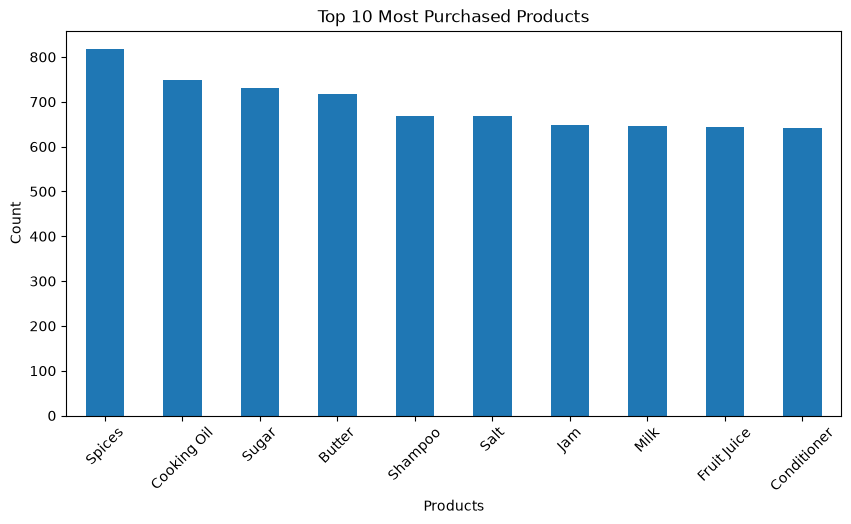

In [10]:
import matplotlib.pyplot as plt

top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Most Purchased Products")
plt.xlabel("Products")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [11]:
basket = (
    df.groupby(["InvoiceNo", "Description"])["Quantity"]
      .sum()
      .unstack()
      .fillna(0)
)

basket.head()

Description,Apple,Banana,Biscuits,Bread,Butter,Carrot,Cheese,Chicken,Chips,Chocolate,...,Soft Drink,Spices,Sugar,Tea,Tissue Paper,Tomato,Toothbrush,Toothpaste,Wheat Flour,Yogurt
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
100001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0
100002,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,...,0.0,0.0,0.0,0.0,3.0,0.0,2.0,0.0,0.0,0.0
100003,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0
100004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
100005,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
basket = basket > 0

basket.head()

Description,Apple,Banana,Biscuits,Bread,Butter,Carrot,Cheese,Chicken,Chips,Chocolate,...,Soft Drink,Spices,Sugar,Tea,Tissue Paper,Tomato,Toothbrush,Toothpaste,Wheat Flour,Yogurt
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
100001,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,False,False,True,False,False,False
100002,False,False,False,True,False,False,False,False,True,True,...,False,False,False,False,True,False,True,False,False,False
100003,True,False,False,False,False,False,False,False,False,False,...,True,False,False,True,False,True,False,False,False,False
100004,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
100005,False,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [13]:
from mlxtend.frequent_patterns import apriori
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

In [14]:
frequent_itemsets.head()

,support,itemsets
0,0.1114,frozenset({Apple})
1,0.1170,frozenset({Banana})
2,0.1224,frozenset({Biscuits})
3,0.1280,frozenset({Bread})
4,0.1436,frozenset({Butter})


In [15]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

In [16]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Apple}),frozenset({Banana}),0.1114,0.1170,0.0256,0.229803,1.964124,1.0,0.012566,1.146459,0.552405,0.126233,0.127749,0.224303
1,frozenset({Banana}),frozenset({Apple}),0.1170,0.1114,0.0256,0.218803,1.964124,1.0,0.012566,1.137486,0.555908,0.126233,0.120868,0.224303
2,frozenset({Sugar}),frozenset({Biscuits}),0.1462,0.1224,0.0288,0.196990,1.609399,1.0,0.010905,1.092889,0.443488,0.120100,0.084994,0.216142
3,frozenset({Biscuits}),frozenset({Sugar}),0.1224,0.1462,0.0288,0.235294,1.609399,1.0,0.010905,1.116508,0.431461,0.120100,0.104350,0.216142
4,frozenset({Biscuits}),frozenset({Tea}),0.1224,0.1050,0.0264,0.215686,2.054155,1.0,0.013548,1.141125,0.584756,0.131343,0.123672,0.233557


In [17]:
rules = rules.sort_values(
    by="lift",
    ascending=False
)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
63,frozenset({Rice}),"frozenset({Cooking Oil, Salt})",0.1168,0.0338,0.0218,0.186644,5.522007,1.0,0.017852,1.187917,0.927204,0.169255,0.158191,0.415807
62,"frozenset({Cooking Oil, Salt})",frozenset({Rice}),0.0338,0.1168,0.0218,0.644970,5.522007,1.0,0.017852,2.487680,0.847554,0.169255,0.598019,0.415807
75,frozenset({Rice}),"frozenset({Spices, Salt})",0.1168,0.0322,0.0206,0.176370,5.477325,1.0,0.016839,1.175042,0.925531,0.160436,0.148967,0.408061
74,"frozenset({Spices, Salt})",frozenset({Rice}),0.0322,0.1168,0.0206,0.639752,5.477325,1.0,0.016839,2.451641,0.844626,0.160436,0.592110,0.408061
72,"frozenset({Rice, Spices})",frozenset({Salt}),0.0334,0.1336,0.0206,0.616766,4.616515,1.0,0.016138,2.260763,0.810456,0.140710,0.557671,0.385479
77,frozenset({Salt}),"frozenset({Rice, Spices})",0.1336,0.0334,0.0206,0.154192,4.616515,1.0,0.016138,1.142812,0.904186,0.140710,0.124965,0.385479
60,"frozenset({Rice, Cooking Oil})",frozenset({Salt}),0.0360,0.1336,0.0218,0.605556,4.532601,1.0,0.016990,2.196507,0.808481,0.147497,0.544732,0.384365
65,frozenset({Salt}),"frozenset({Rice, Cooking Oil})",0.1336,0.0360,0.0218,0.163174,4.532601,1.0,0.016990,1.151971,0.899557,0.147497,0.131923,0.384365
71,frozenset({Cooking Oil}),"frozenset({Rice, Spices})",0.1496,0.0334,0.0214,0.143048,4.282878,1.0,0.016403,1.127951,0.901355,0.132426,0.113437,0.391883
66,"frozenset({Rice, Spices})",frozenset({Cooking Oil}),0.0334,0.1496,0.0214,0.640719,4.282878,1.0,0.016403,2.366947,0.792998,0.132426,0.577515,0.391883


In [18]:
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

rules.head()

,antecedents,consequents,support,confidence,lift
63,frozenset({Rice}),"frozenset({Cooking Oil, Salt})",0.0218,0.186644,5.522007
62,"frozenset({Cooking Oil, Salt})",frozenset({Rice}),0.0218,0.644970,5.522007
75,frozenset({Rice}),"frozenset({Spices, Salt})",0.0206,0.176370,5.477325
74,"frozenset({Spices, Salt})",frozenset({Rice}),0.0206,0.639752,5.477325
72,"frozenset({Rice, Spices})",frozenset({Salt}),0.0206,0.616766,4.616515


In [23]:
def recommend(product_name):

    product_name = product_name.lower()

    recommendations = rules[
        rules["antecedents"].apply(
            lambda items: any(
                item.lower() == product_name
                for item in items
            )
        )
    ].copy()

    recommendations = recommendations.sort_values(
        by="lift",
        ascending=False
    )

    # Convert frozenset to readable text
    recommendations["Recommended Product"] = recommendations["consequents"].apply(
        lambda x: ", ".join(list(x))
    )

    return recommendations[
        [
            "Recommended Product",
            "confidence",
            "lift"
        ]
    ]

In [24]:
recommend("milk")

,Recommended Product,confidence,lift
30,Coffee,0.212403,1.988793
20,Cheese,0.220155,1.792793
19,Butter,0.232558,1.619486
13,Bread,0.203101,1.586725
47,Sugar,0.220155,1.505848


In [25]:
recommend("Tea")

,Recommended Product,confidence,lift
5,Biscuits,0.251429,2.054155
57,Sugar,0.281905,1.928213


In [22]:
recommend("Rice")

,consequents,confidence,lift
63,"frozenset({Cooking Oil, Salt})",0.186644,5.522007
75,"frozenset({Spices, Salt})",0.176370,5.477325
72,frozenset({Salt}),0.616766,4.616515
60,frozenset({Salt}),0.605556,4.532601
66,frozenset({Cooking Oil}),0.640719,4.282878
61,frozenset({Cooking Oil}),0.637427,4.260875
69,"frozenset({Spices, Cooking Oil})",0.183219,3.708890
73,frozenset({Spices}),0.602339,3.681780
67,frozenset({Spices}),0.594444,3.633523
48,frozenset({Salt}),0.292808,2.191678
